### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Understand the dataset

In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Check missing values

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df.drop('Cabin', axis=1, inplace=True)

### Check duplicate records

In [12]:
df.duplicated().sum()

0

In [13]:
df.drop_duplicates(inplace=True)

### Check the target variable

In [15]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [16]:
df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

### Visualization

#### Survival distribution

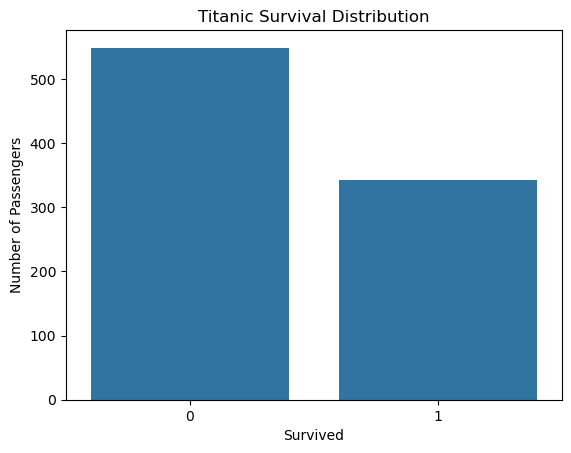

In [17]:
sns.countplot(x='Survived', data=df)

plt.title('Titanic Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')

plt.show()

#### Analyzing gender vs survival

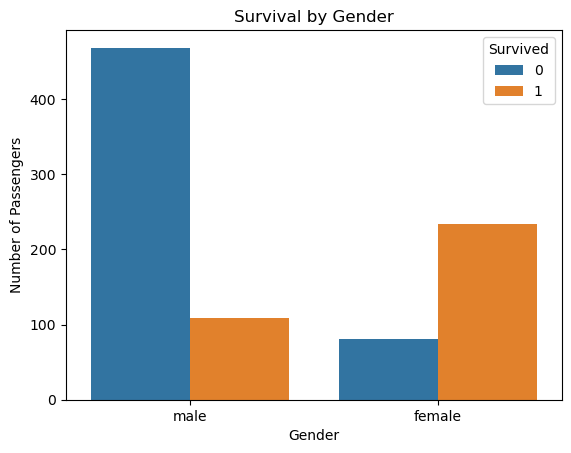

In [19]:
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

In [20]:
df.groupby('Sex')['Survived'].mean() * 100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

#### Analyzing passenger class

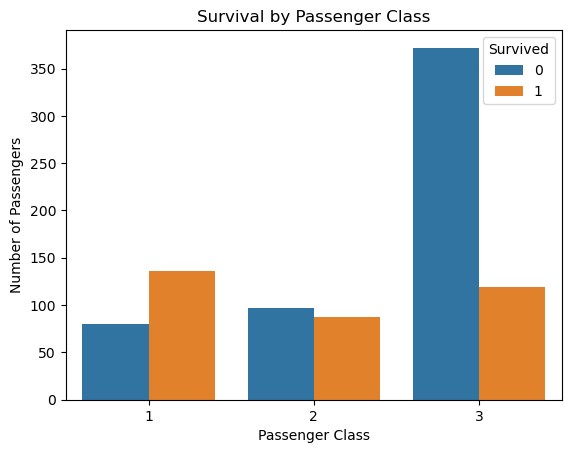

In [21]:
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

In [22]:
df.groupby('Pclass')['Survived'].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

#### Analyzing age

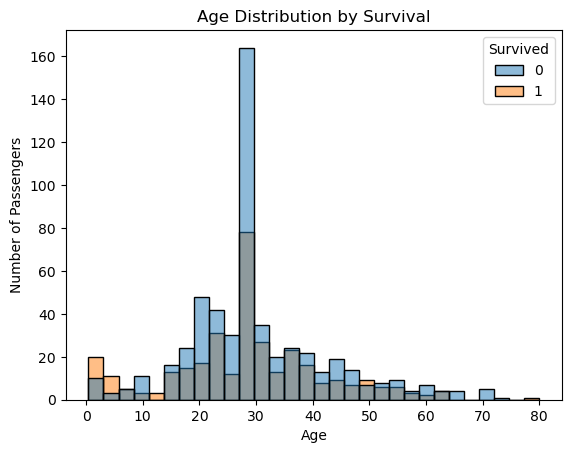

In [23]:
sns.histplot(data=df, x='Age', hue='Survived', bins=30)

plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

In [24]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

In [25]:
df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

#### Analyzing fare

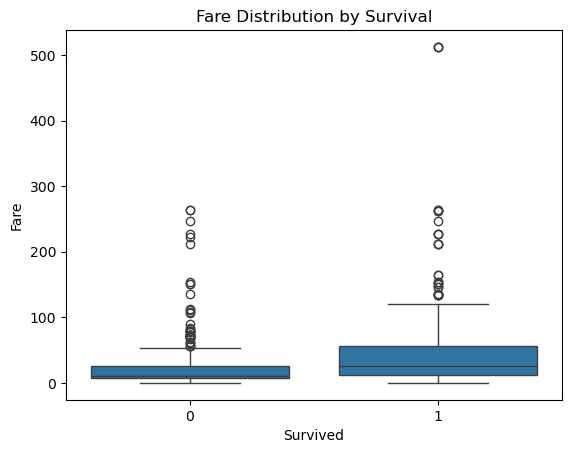

In [26]:
sns.boxplot(x='Survived', y='Fare', data=df)

plt.title('Fare Distribution by Survival')
plt.xlabel('Survived')
plt.ylabel('Fare')

plt.show()

#### Analyzing family size

In [27]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

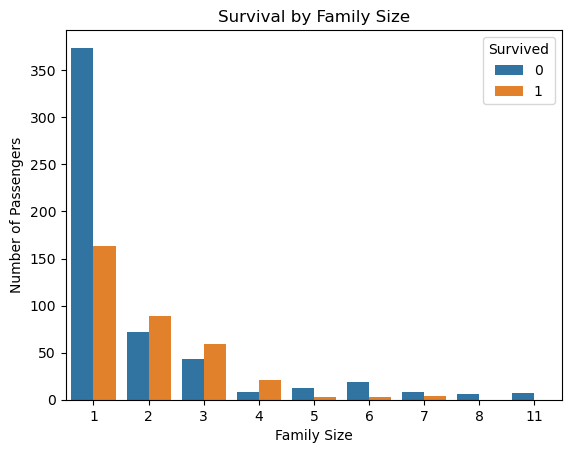

In [28]:
sns.countplot(x='FamilySize', hue='Survived', data=df)

plt.title('Survival by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Number of Passengers')

plt.show()

In [29]:
df['FamilyType'] = pd.cut(
    df['FamilySize'],
    bins=[0, 1, 4, 7, 20],
    labels=['Alone', 'Small Family', 'Medium Family', 'Large Family']
)

In [30]:
df.groupby('FamilyType', observed=True)['Survived'].mean() * 100

FamilyType
Alone            30.353818
Small Family     57.876712
Medium Family    20.408163
Large Family      0.000000
Name: Survived, dtype: float64

#### Analyzing embarkation port

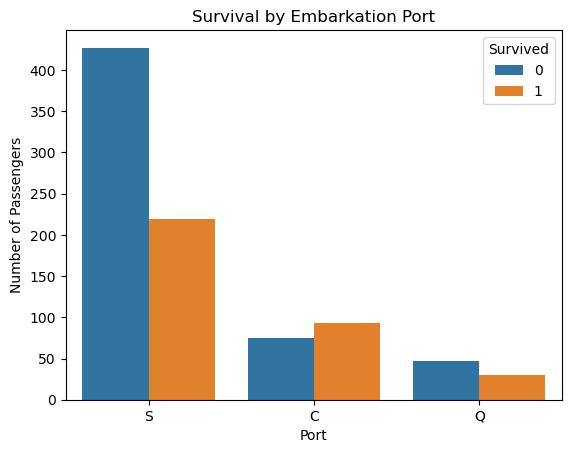

In [31]:
sns.countplot(x='Embarked', hue='Survived', data=df)

plt.title('Survival by Embarkation Port')
plt.xlabel('Port')
plt.ylabel('Number of Passengers')

plt.show()

In [32]:
df.groupby('Embarked')['Survived'].mean() * 100

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

#### Creating a correlation heatmap

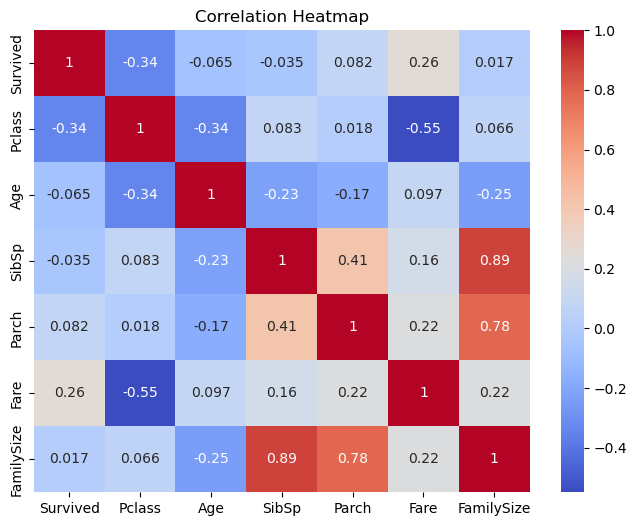

In [33]:
numeric_cols = [
    'Survived',
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize'
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Summary

In [34]:
summary = pd.DataFrame({
    'Metric': [
        'Total Passengers',
        'Survivors',
        'Non-Survivors',
        'Overall Survival Rate'
    ],
    'Value': [
        len(df),
        df['Survived'].sum(),
        (df['Survived'] == 0).sum(),
        df['Survived'].mean() * 100
    ]
})

summary

,Metric,Value
0,Total Passengers,891.000000
1,Survivors,342.000000
2,Non-Survivors,549.000000
3,Overall Survival Rate,38.383838
